<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Assignment_8 : Supervised Learning Classifiation**



**About data set**:

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

**content:**

The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

**Objective**

build a machine learning model to accurately predict whether or not the patients in the dataset have diabetes or not?

Import all the necessary libraries for data handling, visualization, and model building

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

1.loading the data set

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data_set/diabetes.csv')
df.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


Discovering the data set

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


the data set contains 768 rows and 9 columns and all column are important discovering diabets

Checking the missing values.

In [ ]:
df.isnull().sum()
df.isin(["NA", "N/A", "Unknown"]).sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


there is no null values.

**EDA : Process**

relation  features with target variable


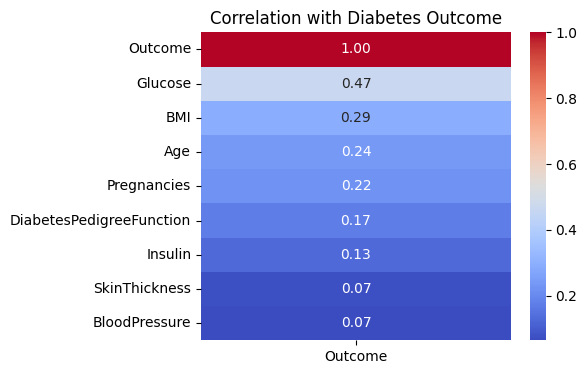

In [ ]:
corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix[["Outcome"]].sort_values(
    by="Outcome",
    ascending=False)
plt.figure(figsize=(5, 4))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Diabetes Outcome")
plt.show()

The highly correlated features are glucose, BMI,Age pregnancies ,DiabetesPedigreeFunctin,Insulin

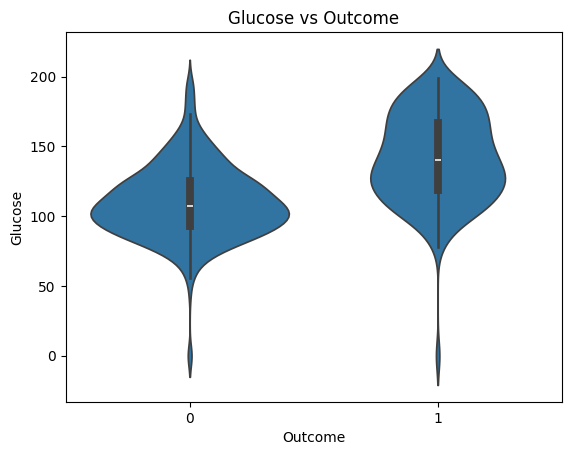

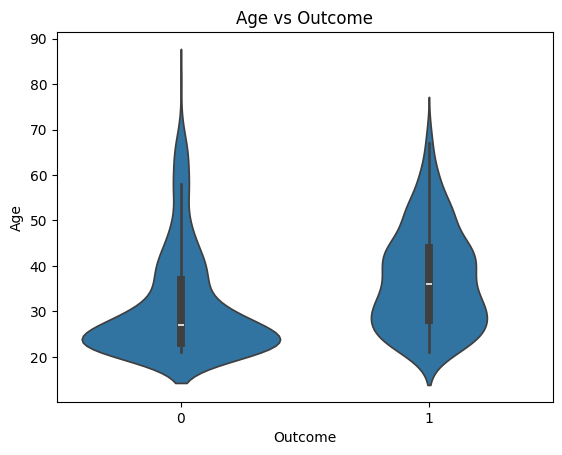

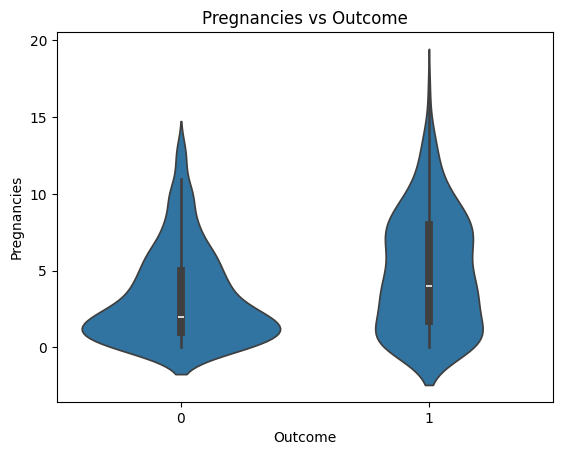

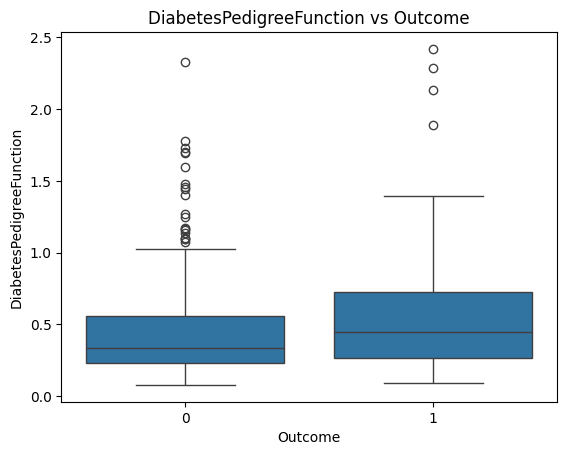

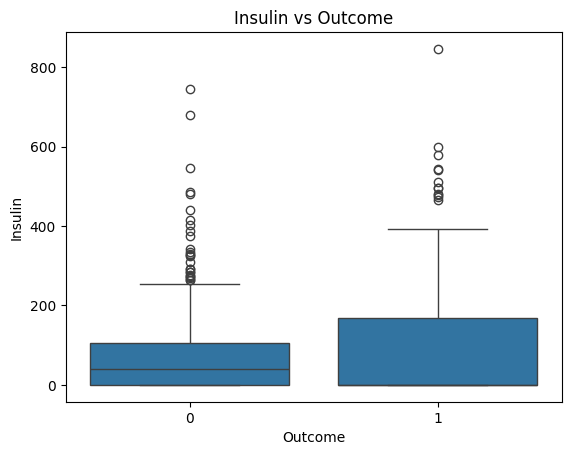

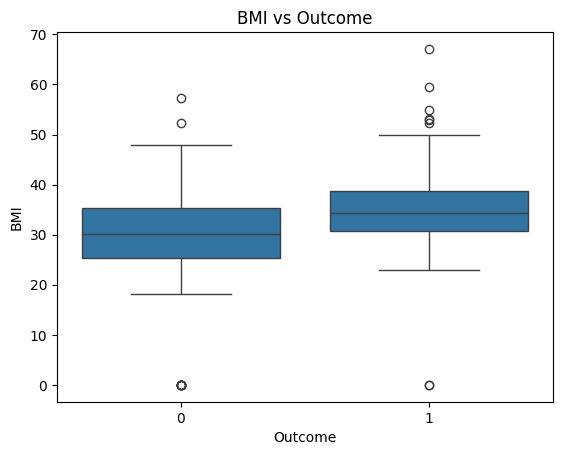

In [ ]:
def plot_feature(df, kind, target="Outcome", features=None):
    if features is None:
        numerical_cols = df.select_dtypes(include="number").columns
        features = numerical_cols.drop(target, errors='ignore')
    for feature in features:
        plt.figure()
        if kind == "violin":
            sns.violinplot(data=df, x=target, y=feature)
        elif kind == "box":
            sns.boxplot(data=df, x=target, y=feature)
        else:
            raise ValueError("kind must be 'violin' or 'box'")
        plt.title(f"{feature} vs {target}")
        plt.show()

features_violin = ['Glucose', 'Age', 'Pregnancies']
features_box = ['DiabetesPedigreeFunction', 'Insulin', 'BMI']

plot_feature(df, "violin", features=features_violin)
plot_feature(df, "box", features=features_box)


**Findings**

The visual analysis clearly shows that glucose is the strongest indicator of diabetes, as higher glucose levels are mostly associated with the presence of disease. Age also plays an important role, where individuals above 40 years show a higher likelihood of diabetes.
similarly , BMI above 30 is linked with a higher chance of diabetes, suggesting that obesity is a significant risk factor. pregnancies above 6 may also indicate an increased risk, although it is not a strong standalone predictor and should be interpreted with other features . on the other hand, insulin shows an unclear pattern due to outliners and inconsistent values across both classes. overall, the analysis confirms that Glucose, Age, and BMI are the most reliable indicators of diabetes presence, while other features provide weaker or supporting signals.


**Data Preprocessing**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


The data is clean, well-structured, and ready for model building. all variables are in the correct format, and there are no missing or inconsistent values that could affect the training process.

**Splitting Data set**

In [ ]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

**Build Model & Evaluate the model**

In [ ]:
lr_model = Pipeline([ ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))])

lr_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')
print("Logistic Regression CV Scores:", lr_scores)
print("Mean CV Accuracy:", lr_scores.mean())

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("Classification Report:\n", classification_report(y_test,y_pred))

Logistic Regression CV Scores: [0.75609756 0.7804878  0.7804878  0.7804878  0.79508197]
Mean CV Accuracy: 0.7785285885645742
Accuracy: 0.7142857142857143
Confusion Matrix:
 [[82 18]
 [26 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



**Inconculusion**
for evaluating the model lets start with mean cross validation accuracy of about 0.78 indicating fairly stable learning during training. however the test accuracy drops to 0.71 , suggesting a slight gap between training validation and real performance , which may indicate mild overfitting or dataset variability.

confusion matrix number indicates that the model correctly predicted class 0 82 out of 100 cases, incorrectly predicted class 0 as class 1 in 18 cases (false positives). for class 1, it correctly predicted 28 out of 54 cases, while 26 were incorrectly predicted as class 0 (false negatives).

The classification report confirms this pattern : class 0 has strong precision and recall (0.76 to 0.82) while  class 1 has weaker performance , especially in recall(0.52) this model has problem in identify class 1
In summary , the model is reasonably reliable but biased to ward class 0 and it struggles with detecting class 1 , may there is class imbalance or limited feature separation.